# MSE Embedding Context-Mean (5p) vs Random

This notebook compares `mse_embedding_context_mean_*` encoder policies against `random` for:
- `iterations_used` (prompt/click cost; lower is better)
- `initial_dice` (higher is better)

All summaries use the same hierarchical bootstrap path used across the repo:
`compute_subset_scores` -> `hierarchical_bootstrap_task_estimates` -> `dataset_bootstrap_stats`.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path('/data/ddmg/mvseg-ordering')
for path in [repo_root, repo_root / 'UniverSeg', repo_root / 'MultiverSeg']:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from experiments.analysis.planb_utils import load_planb_summaries
from experiments.analysis.hierarchical_ci import (
    compute_subset_scores,
    hierarchical_bootstrap_task_estimates,
    dataset_bootstrap_stats,
)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)


In [2]:
# --- Config ---
procedure = 'random_v_MSE_v2'
ablation = 'pretrained_baseline5p_mse_embedding_context_mean'
dataset = None  # e.g. 'BTCV' or None for all available families

baseline_policy = 'random'
policy_prefix = 'mse_embedding_context_mean_'
metrics = ['iterations_used', 'initial_dice']

n_boot = 1000
seed = 0
alpha = 0.05

out_dir = repo_root / 'figures' / 'mse_context_mean_embedding_5p_pretrained_baseline'
out_dir.mkdir(parents=True, exist_ok=True)


In [3]:
raw_df = load_planb_summaries(
    repo_root=repo_root,
    procedure=procedure,
    ablation=ablation,
    dataset=dataset,
    filename='subset_support_images_summary.csv',
)

all_policies = sorted(raw_df['policy_name'].unique())
encoder_policies = sorted([p for p in all_policies if p.startswith(policy_prefix)])
if baseline_policy not in all_policies:
    raise ValueError(f"Baseline policy '{baseline_policy}' is missing. Found: {all_policies}")
if not encoder_policies:
    raise ValueError(f"No encoder policies found with prefix '{policy_prefix}'. Found: {all_policies}")

analysis_policies = [baseline_policy] + encoder_policies
analysis_df = raw_df[raw_df['policy_name'].isin(analysis_policies)].copy()

print(f'Loaded rows: {len(raw_df):,}')
print(f'Rows used in analysis: {len(analysis_df):,}')
print(f'Families: {sorted(analysis_df["family"].unique())}')
print(f'Policies: {analysis_policies}')


Loaded rows: 570,000
Rows used in analysis: 570,000
Families: ['ACDC', 'BTCV', 'BUID', 'WBC']
Policies: ['random', 'mse_embedding_context_mean_clip', 'mse_embedding_context_mean_dinov2', 'mse_embedding_context_mean_medsam', 'mse_embedding_context_mean_multiverseg', 'mse_embedding_context_mean_vit']


In [4]:
PAIR_KEYS = ['family', 'task_id', 'subset_index']


def _hierarchical_mean_ci(df: pd.DataFrame, value_col: str):
    subset_scores_by_task = {
        str(task_id): grp[value_col].to_numpy(dtype=float)
        for task_id, grp in df.groupby('task_id')
    }
    task_boot = hierarchical_bootstrap_task_estimates(
        subset_scores_by_task,
        n_boot=n_boot,
        seed=seed,
    )
    _, mean, ci_lo, ci_hi = dataset_bootstrap_stats(task_boot, alpha=alpha)
    return mean, ci_lo, ci_hi, int(df['task_id'].nunique()), int(len(df))


def _encoder_name(policy_name: str) -> str:
    return policy_name[len(policy_prefix):] if policy_name.startswith(policy_prefix) else policy_name


absolute_rows = []
delta_rows = []

for metric in metrics:
    subset_df = compute_subset_scores(
        analysis_df,
        metric,
        extra_group_cols=['family'],
    ).rename(columns={'subset_mean': 'score'})

    # Absolute policy means + CIs
    for (family, policy_name), group_df in subset_df.groupby(['family', 'policy_name']):
        mean, ci_lo, ci_hi, n_tasks, n_subsets = _hierarchical_mean_ci(group_df, 'score')
        absolute_rows.append(
            {
                'family': family,
                'metric': metric,
                'policy_name': policy_name,
                'encoder': _encoder_name(policy_name),
                'mean': mean,
                'ci_lo': ci_lo,
                'ci_hi': ci_hi,
                'n_tasks': n_tasks,
                'n_subsets': n_subsets,
            }
        )

    # Paired deltas vs random
    baseline_subset = subset_df[subset_df['policy_name'] == baseline_policy][PAIR_KEYS + ['score']].rename(
        columns={'score': 'baseline_score'}
    )

    for policy_name in encoder_policies:
        policy_subset = subset_df[subset_df['policy_name'] == policy_name][PAIR_KEYS + ['score']]
        paired = policy_subset.merge(
            baseline_subset,
            on=PAIR_KEYS,
            how='inner',
            validate='one_to_one',
        )
        if paired.empty:
            continue
        paired['delta'] = paired['score'] - paired['baseline_score']

        for family, family_df in paired.groupby('family'):
            mean, ci_lo, ci_hi, n_tasks, n_pairs = _hierarchical_mean_ci(family_df, 'delta')
            if metric == 'iterations_used':
                beats_random = ci_hi < 0.0
            elif metric == 'initial_dice':
                beats_random = ci_lo > 0.0
            else:
                beats_random = False

            delta_rows.append(
                {
                    'family': family,
                    'metric': metric,
                    'policy_name': policy_name,
                    'encoder': _encoder_name(policy_name),
                    'mean_delta': mean,
                    'ci_lo': ci_lo,
                    'ci_hi': ci_hi,
                    'beats_random': beats_random,
                    'n_tasks': n_tasks,
                    'n_pairs': n_pairs,
                }
            )

absolute_summary = pd.DataFrame(absolute_rows).sort_values(['family', 'metric', 'policy_name']).reset_index(drop=True)
delta_summary = pd.DataFrame(delta_rows).sort_values(['family', 'metric', 'policy_name']).reset_index(drop=True)

print('Absolute summary rows:', len(absolute_summary))
print('Delta summary rows:', len(delta_summary))


Absolute summary rows: 48
Delta summary rows: 40


In [5]:
# Absolute values (includes random + all encoders)
absolute_summary


,family,metric,policy_name,encoder,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,initial_dice,mse_embedding_context_mean_clip,clip,0.577558,0.563988,0.591601,6,60
1,ACDC,initial_dice,mse_embedding_context_mean_dinov2,dinov2,0.584971,0.574450,0.595613,6,60
2,ACDC,initial_dice,mse_embedding_context_mean_medsam,medsam,0.578853,0.564924,0.593159,6,60
3,ACDC,initial_dice,mse_embedding_context_mean_multiverseg,multiverseg,0.581650,0.570133,0.593569,6,60
4,ACDC,initial_dice,mse_embedding_context_mean_vit,vit,0.585174,0.574887,0.596275,6,60
5,ACDC,initial_dice,random,random,0.578260,0.566655,0.590195,6,60
6,ACDC,iterations_used,mse_embedding_context_mean_clip,clip,3.425651,3.324833,3.517517,6,60
7,ACDC,iterations_used,mse_embedding_context_mean_dinov2,dinov2,3.396509,3.298663,3.485179,6,60
8,ACDC,iterations_used,mse_embedding_context_mean_medsam,medsam,3.443471,3.341475,3.535679,6,60
9,ACDC,iterations_used,mse_embedding_context_mean_multiverseg,multiverseg,3.440759,3.346317,3.530696,6,60


In [6]:
# Delta vs random (policy - random) and whether each policy beats random
# - iterations_used: beat if CI upper bound < 0
# - initial_dice:   beat if CI lower bound > 0
delta_summary


,family,metric,policy_name,encoder,mean_delta,ci_lo,ci_hi,beats_random,n_tasks,n_pairs
0,ACDC,initial_dice,mse_embedding_context_mean_clip,clip,-0.000702,-0.003943,0.002325,False,6,60
1,ACDC,initial_dice,mse_embedding_context_mean_dinov2,dinov2,0.006712,0.003601,0.010115,True,6,60
2,ACDC,initial_dice,mse_embedding_context_mean_medsam,medsam,0.000593,-0.004735,0.004785,False,6,60
3,ACDC,initial_dice,mse_embedding_context_mean_multiverseg,multiverseg,0.003391,-0.000128,0.006605,False,6,60
4,ACDC,initial_dice,mse_embedding_context_mean_vit,vit,0.006915,0.003494,0.010342,True,6,60
5,ACDC,iterations_used,mse_embedding_context_mean_clip,clip,-0.000138,-0.015169,0.014517,False,6,60
6,ACDC,iterations_used,mse_embedding_context_mean_dinov2,dinov2,-0.029280,-0.045151,-0.013732,True,6,60
7,ACDC,iterations_used,mse_embedding_context_mean_medsam,medsam,0.017682,0.001129,0.033740,False,6,60
8,ACDC,iterations_used,mse_embedding_context_mean_multiverseg,multiverseg,0.014970,-0.004757,0.036170,False,6,60
9,ACDC,iterations_used,mse_embedding_context_mean_vit,vit,0.008696,-0.004552,0.023067,False,6,60


In [7]:
# Compact view: only the beat/not-beat verdict by family and encoder
verdict_table = (
    delta_summary[['family', 'metric', 'encoder', 'mean_delta', 'ci_lo', 'ci_hi', 'beats_random']]
    .sort_values(['family', 'metric', 'encoder'])
    .reset_index(drop=True)
)
verdict_table


,family,metric,encoder,mean_delta,ci_lo,ci_hi,beats_random
0,ACDC,initial_dice,clip,-0.000702,-0.003943,0.002325,False
1,ACDC,initial_dice,dinov2,0.006712,0.003601,0.010115,True
2,ACDC,initial_dice,medsam,0.000593,-0.004735,0.004785,False
3,ACDC,initial_dice,multiverseg,0.003391,-0.000128,0.006605,False
4,ACDC,initial_dice,vit,0.006915,0.003494,0.010342,True
5,ACDC,iterations_used,clip,-0.000138,-0.015169,0.014517,False
6,ACDC,iterations_used,dinov2,-0.029280,-0.045151,-0.013732,True
7,ACDC,iterations_used,medsam,0.017682,0.001129,0.033740,False
8,ACDC,iterations_used,multiverseg,0.014970,-0.004757,0.036170,False
9,ACDC,iterations_used,vit,0.008696,-0.004552,0.023067,False


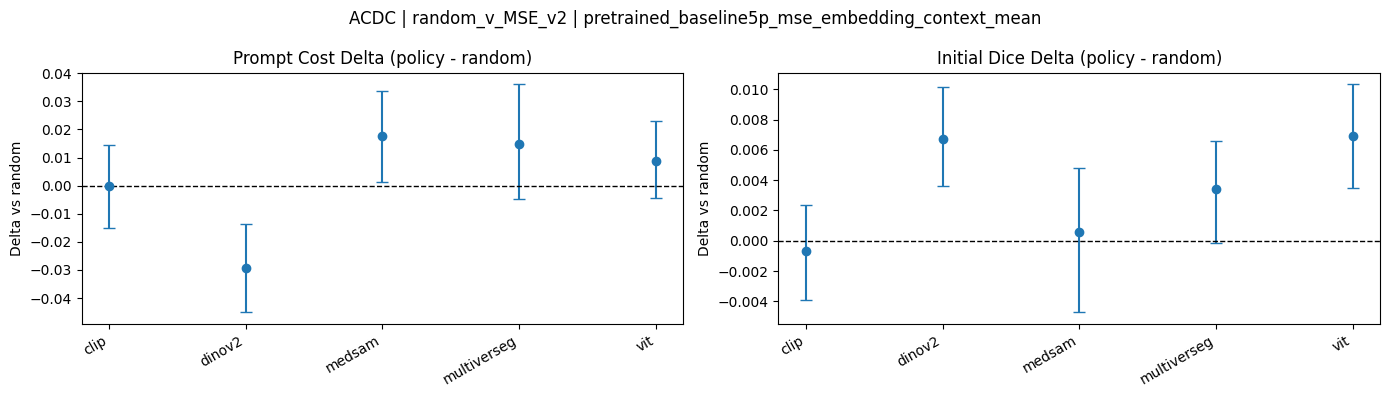

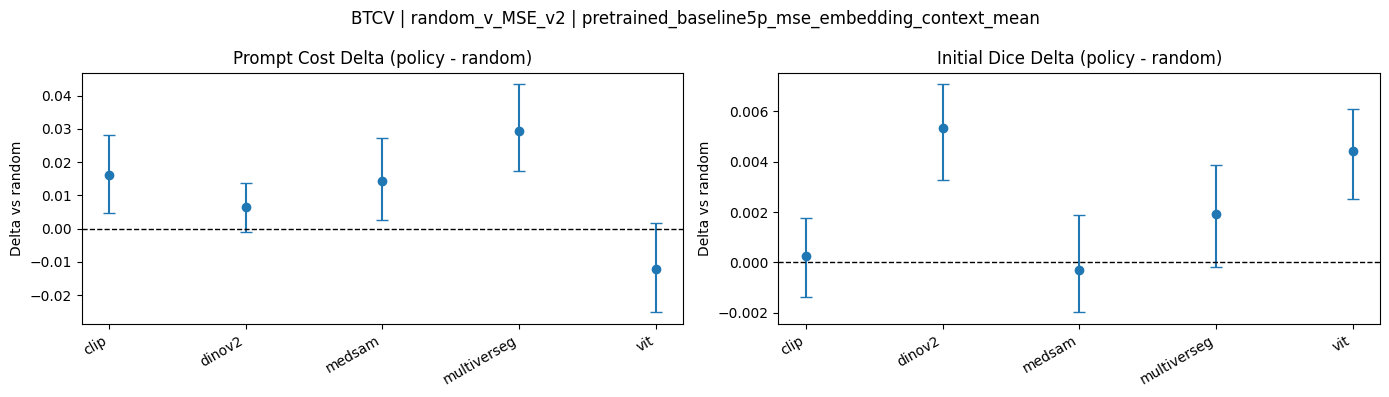

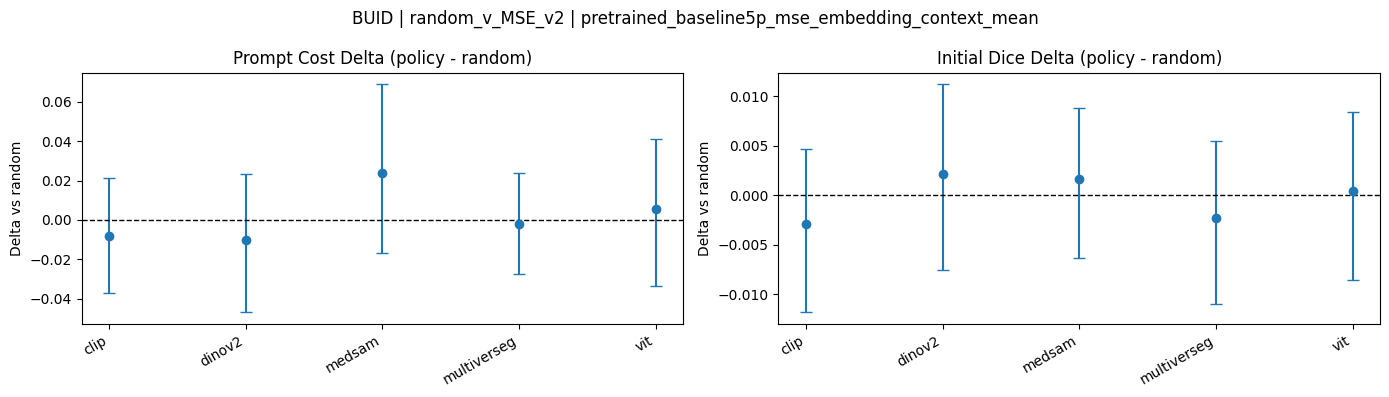

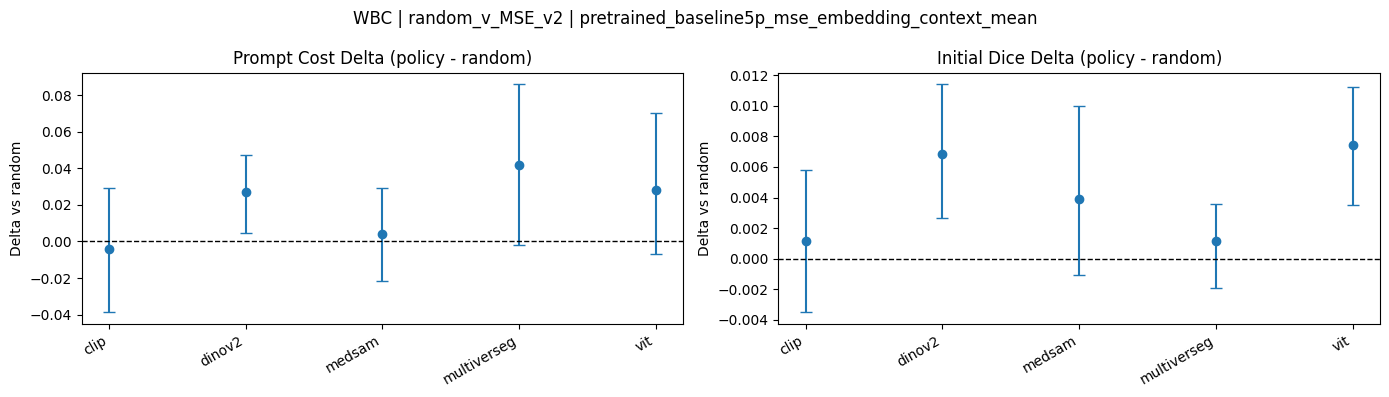

In [8]:
# Plot deltas with CIs (one figure per family)
metric_titles = {
    'iterations_used': 'Prompt Cost Delta (policy - random)',
    'initial_dice': 'Initial Dice Delta (policy - random)',
}

families = sorted(delta_summary['family'].unique()) if not delta_summary.empty else []
for family in families:
    fam_df = delta_summary[delta_summary['family'] == family]
    fig, axes = plt.subplots(1, len(metrics), figsize=(7 * len(metrics), 4), sharey=False)
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        mdf = fam_df[fam_df['metric'] == metric].sort_values('encoder')
        if mdf.empty:
            ax.set_visible(False)
            continue

        x = np.arange(len(mdf))
        y = mdf['mean_delta'].to_numpy(dtype=float)
        lo = mdf['ci_lo'].to_numpy(dtype=float)
        hi = mdf['ci_hi'].to_numpy(dtype=float)
        yerr = np.vstack([y - lo, hi - y])

        ax.errorbar(x, y, yerr=yerr, fmt='o', capsize=4)
        ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels(mdf['encoder'], rotation=30, ha='right')
        ax.set_title(metric_titles.get(metric, metric))
        ax.set_ylabel('Delta vs random')

    fig.suptitle(f'{family} | {procedure} | {ablation}')
    fig.tight_layout()
    plt.show()


## Task-level correlation analysis (all datasets)

This section builds one task-level row per `(family, task_id, encoder)` with:
- `x`: a configurable task-level metric (default: random `initial_dice`)
- `y`: task-level `iterations_used` delta (`encoder - random`)

Then it plots scatter charts per dataset and reports Pearson/Spearman correlations.


In [9]:
# --- Task-level scatter config ---
task_x_metric = 'initial_dice'   # try: 'initial_dice' or 'iterations_used'
task_x_policy = baseline_policy  # usually random
task_y_metric = 'iterations_used'


def _safe_corr(x: pd.Series, y: pd.Series, method: str) -> float:
    if len(x) < 3:
        return float('nan')
    if x.nunique() < 2 or y.nunique() < 2:
        return float('nan')
    return float(x.corr(y, method=method))


subset_x = compute_subset_scores(
    analysis_df,
    task_x_metric,
    extra_group_cols=['family'],
).rename(columns={'subset_mean': 'subset_x'})

subset_y = compute_subset_scores(
    analysis_df,
    task_y_metric,
    extra_group_cols=['family'],
).rename(columns={'subset_mean': 'subset_y'})

baseline_task_x = (
    subset_x[subset_x['policy_name'] == task_x_policy]
    .groupby(['family', 'task_id'], as_index=False)['subset_x']
    .mean()
    .rename(columns={'subset_x': 'x_value'})
)

baseline_task_y = (
    subset_y[subset_y['policy_name'] == baseline_policy]
    .groupby(['family', 'task_id'], as_index=False)['subset_y']
    .mean()
    .rename(columns={'subset_y': 'baseline_y'})
)

task_rows = []
for policy_name in encoder_policies:
    policy_task_y = (
        subset_y[subset_y['policy_name'] == policy_name]
        .groupby(['family', 'task_id'], as_index=False)['subset_y']
        .mean()
        .rename(columns={'subset_y': 'policy_y'})
    )

    merged = (
        policy_task_y
        .merge(baseline_task_y, on=['family', 'task_id'], how='inner', validate='one_to_one')
        .merge(baseline_task_x, on=['family', 'task_id'], how='inner', validate='one_to_one')
    )
    merged['iterations_delta'] = merged['policy_y'] - merged['baseline_y']
    merged['policy_name'] = policy_name
    merged['encoder'] = _encoder_name(policy_name)
    task_rows.append(merged)

task_scatter_df = pd.concat(task_rows, ignore_index=True).sort_values(
    ['family', 'encoder', 'task_id']
).reset_index(drop=True)

corr_rows = []
for (family, policy_name), grp in task_scatter_df.groupby(['family', 'policy_name']):
    corr_rows.append(
        {
            'family': family,
            'policy_name': policy_name,
            'encoder': _encoder_name(policy_name),
            'n_tasks': int(len(grp)),
            'pearson_r': _safe_corr(grp['x_value'], grp['iterations_delta'], method='pearson'),
            'spearman_r': _safe_corr(grp['x_value'], grp['iterations_delta'], method='spearman'),
        }
    )

task_corr_df = pd.DataFrame(corr_rows).sort_values(['family', 'encoder']).reset_index(drop=True)

print(f'Task-level rows: {len(task_scatter_df):,}')
print(f'Families: {sorted(task_scatter_df["family"].unique())}')


Task-level rows: 190
Families: ['ACDC', 'BTCV', 'BUID', 'WBC']


In [10]:
# Task-level table
# x_value = task-level mean of random's task_x_metric
# iterations_delta = task-level mean iterations_used(policy) - iterations_used(random)
task_scatter_df.head(20)


,family,task_id,policy_y,baseline_y,x_value,iterations_delta,policy_name,encoder
0,ACDC,ACDC/ACDC_Challenge2017_MRI_2_label0_maxslice_...,2.764,2.7452,0.601110,0.0188,mse_embedding_context_mean_clip,clip
1,ACDC,ACDC/ACDC_Challenge2017_MRI_2_label0_midslice_...,4.084,4.0585,0.499868,0.0255,mse_embedding_context_mean_clip,clip
2,ACDC,ACDC/ACDC_Challenge2017_MRI_2_label1_maxslice_...,4.993,4.9931,0.487206,-0.0001,mse_embedding_context_mean_clip,clip
3,ACDC,ACDC/ACDC_Challenge2017_MRI_2_label1_midslice_...,5.000,5.0000,0.420978,0.0000,mse_embedding_context_mean_clip,clip
4,ACDC,ACDC/ACDC_Challenge2017_MRI_2_label2_maxslice_...,2.255,2.2624,0.732325,-0.0074,mse_embedding_context_mean_clip,clip
5,ACDC,ACDC/ACDC_Challenge2017_MRI_2_label2_midslice_...,1.450,1.4894,0.729453,-0.0394,mse_embedding_context_mean_clip,clip
6,ACDC,ACDC/ACDC_Challenge2017_MRI_2_label0_maxslice_...,2.748,2.7452,0.601110,0.0028,mse_embedding_context_mean_dinov2,dinov2
7,ACDC,ACDC/ACDC_Challenge2017_MRI_2_label0_midslice_...,4.002,4.0585,0.499868,-0.0565,mse_embedding_context_mean_dinov2,dinov2
8,ACDC,ACDC/ACDC_Challenge2017_MRI_2_label1_maxslice_...,4.990,4.9931,0.487206,-0.0031,mse_embedding_context_mean_dinov2,dinov2
9,ACDC,ACDC/ACDC_Challenge2017_MRI_2_label1_midslice_...,5.000,5.0000,0.420978,0.0000,mse_embedding_context_mean_dinov2,dinov2


In [11]:
# Correlation summary table by family + encoder
task_corr_df


,family,policy_name,encoder,n_tasks,pearson_r,spearman_r
0,ACDC,mse_embedding_context_mean_clip,clip,6,-0.576873,-0.485714
1,ACDC,mse_embedding_context_mean_dinov2,dinov2,6,-0.633109,-0.657143
2,ACDC,mse_embedding_context_mean_medsam,medsam,6,0.658477,0.600000
3,ACDC,mse_embedding_context_mean_multiverseg,multiverseg,6,0.732794,0.600000
4,ACDC,mse_embedding_context_mean_vit,vit,6,-0.258120,0.085714
5,BTCV,mse_embedding_context_mean_clip,clip,20,-0.139686,-0.090226
6,BTCV,mse_embedding_context_mean_dinov2,dinov2,20,-0.013900,0.076692
7,BTCV,mse_embedding_context_mean_medsam,medsam,20,-0.485080,-0.479699
8,BTCV,mse_embedding_context_mean_multiverseg,multiverseg,20,-0.418440,-0.410526
9,BTCV,mse_embedding_context_mean_vit,vit,20,-0.009894,-0.096241


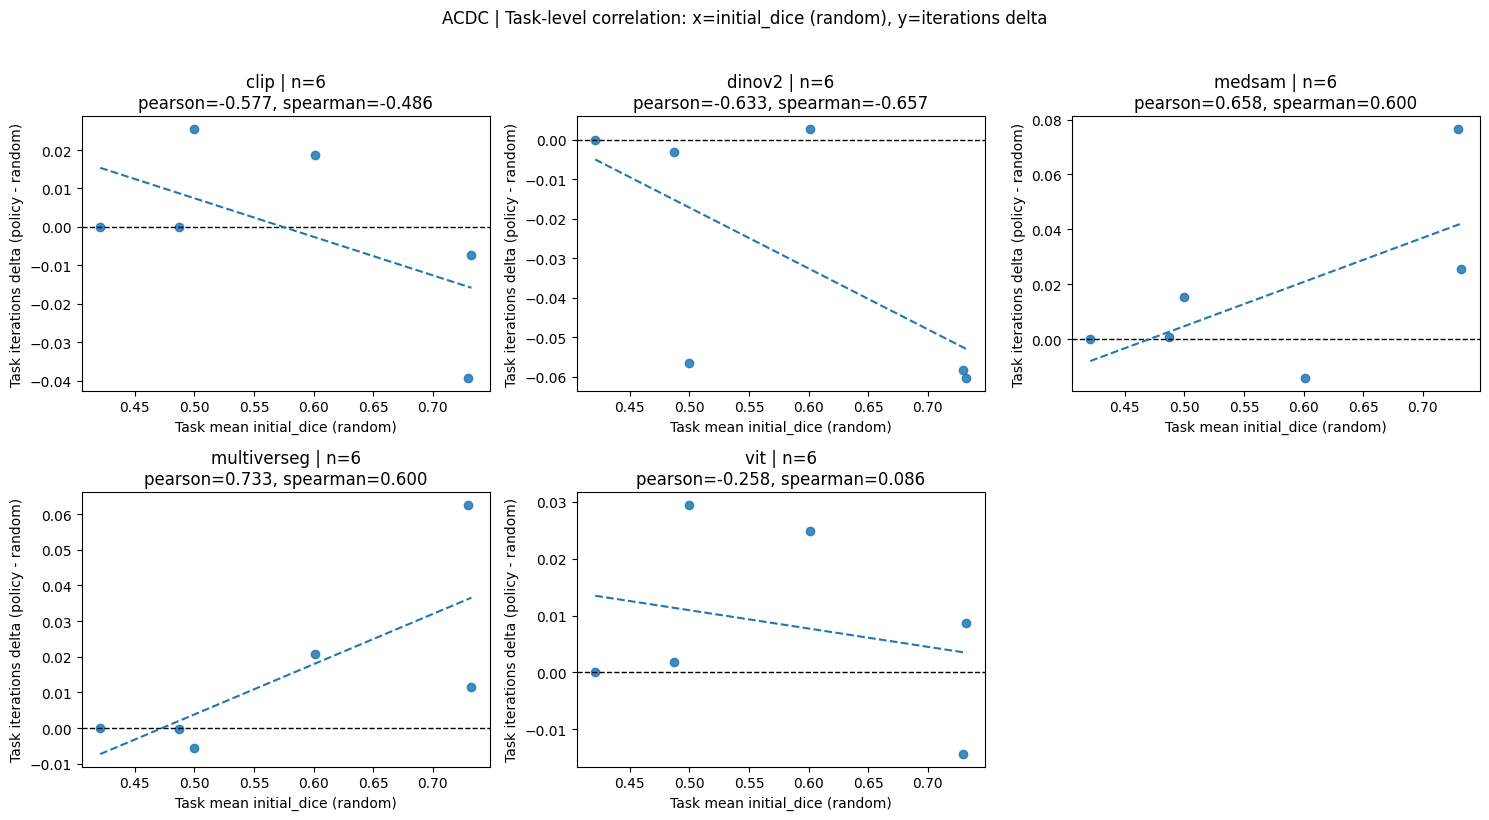

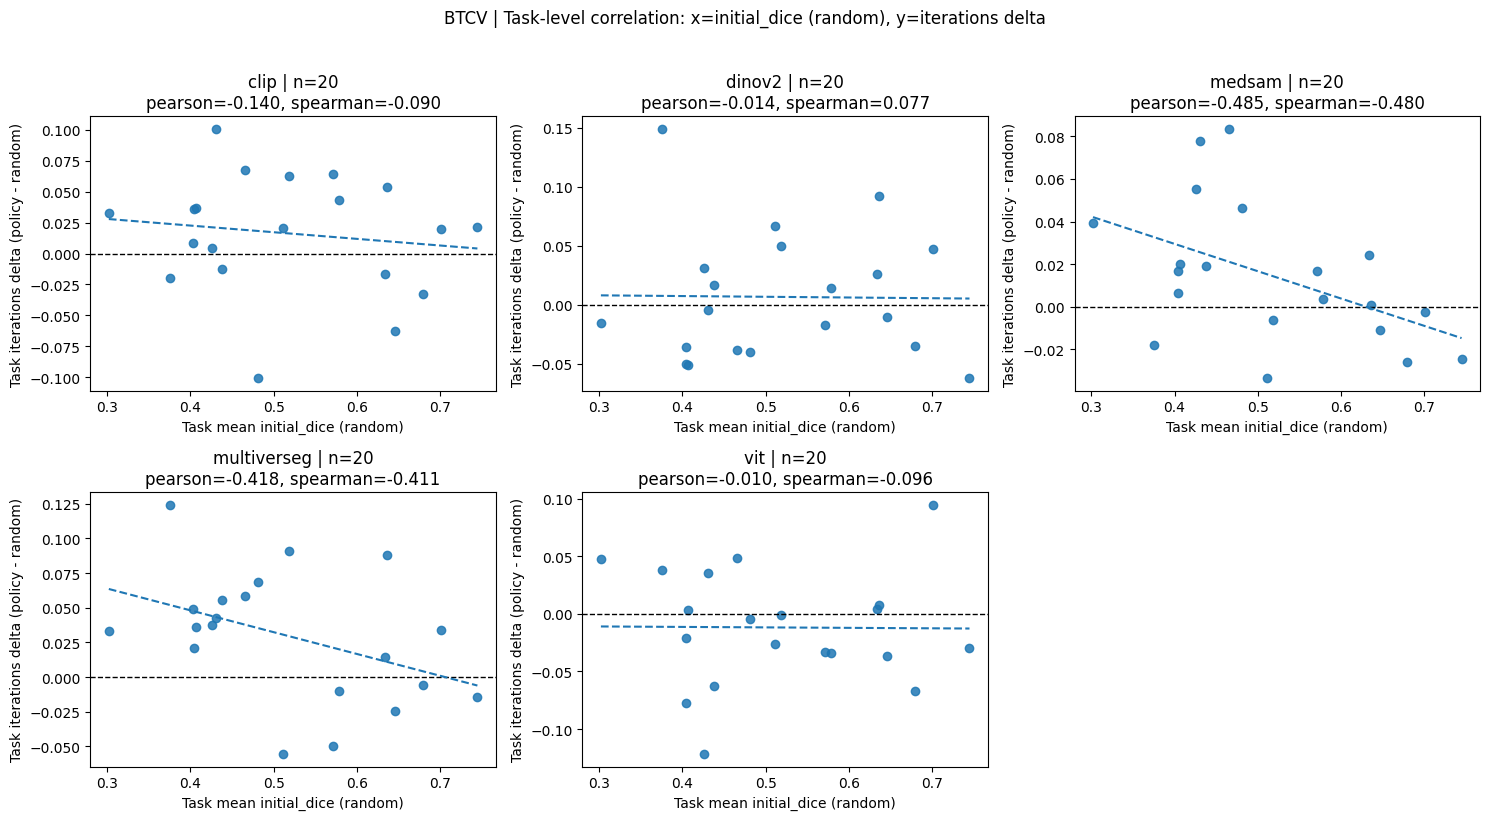

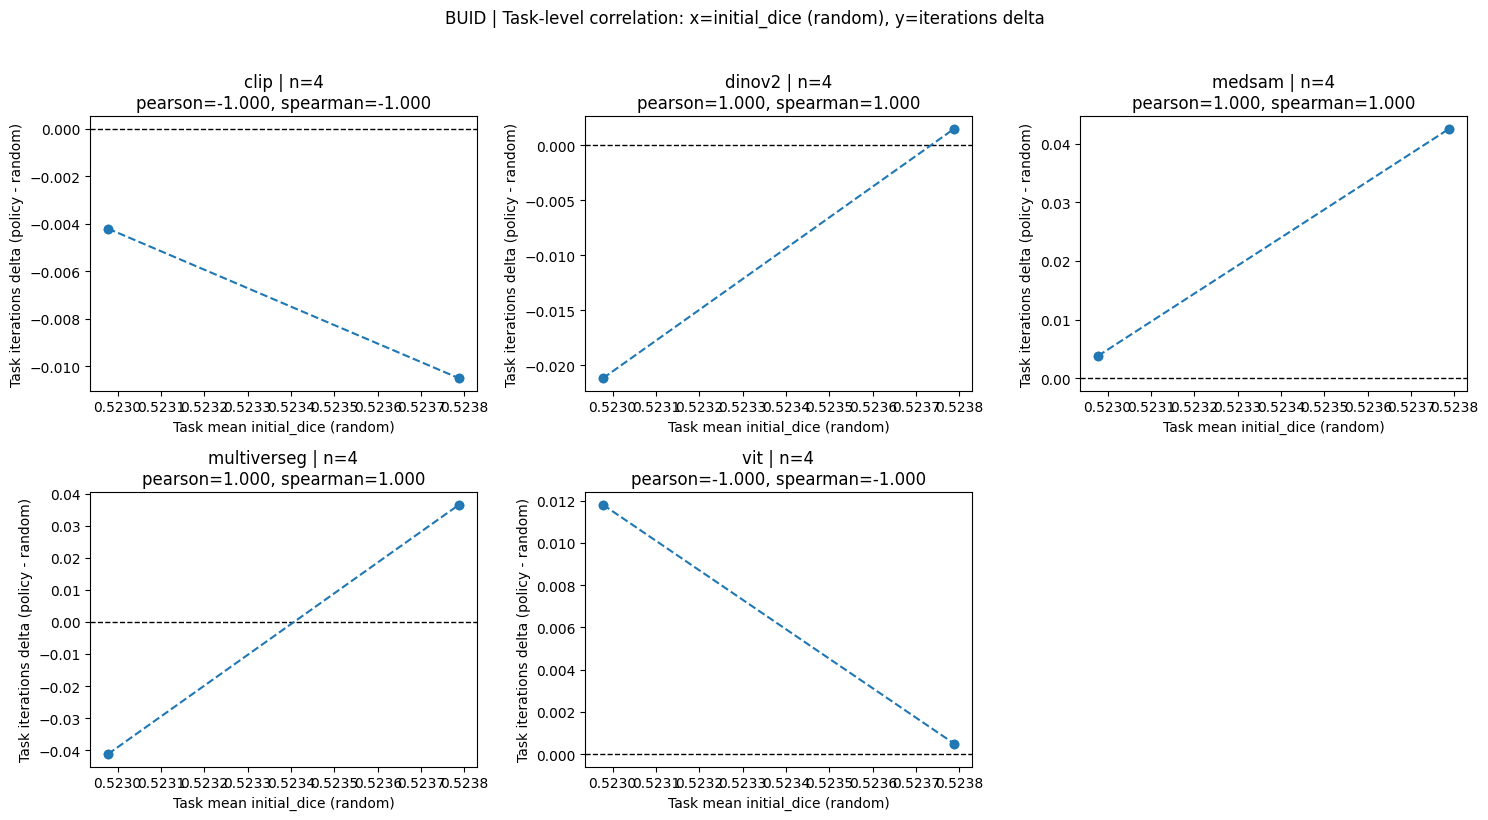

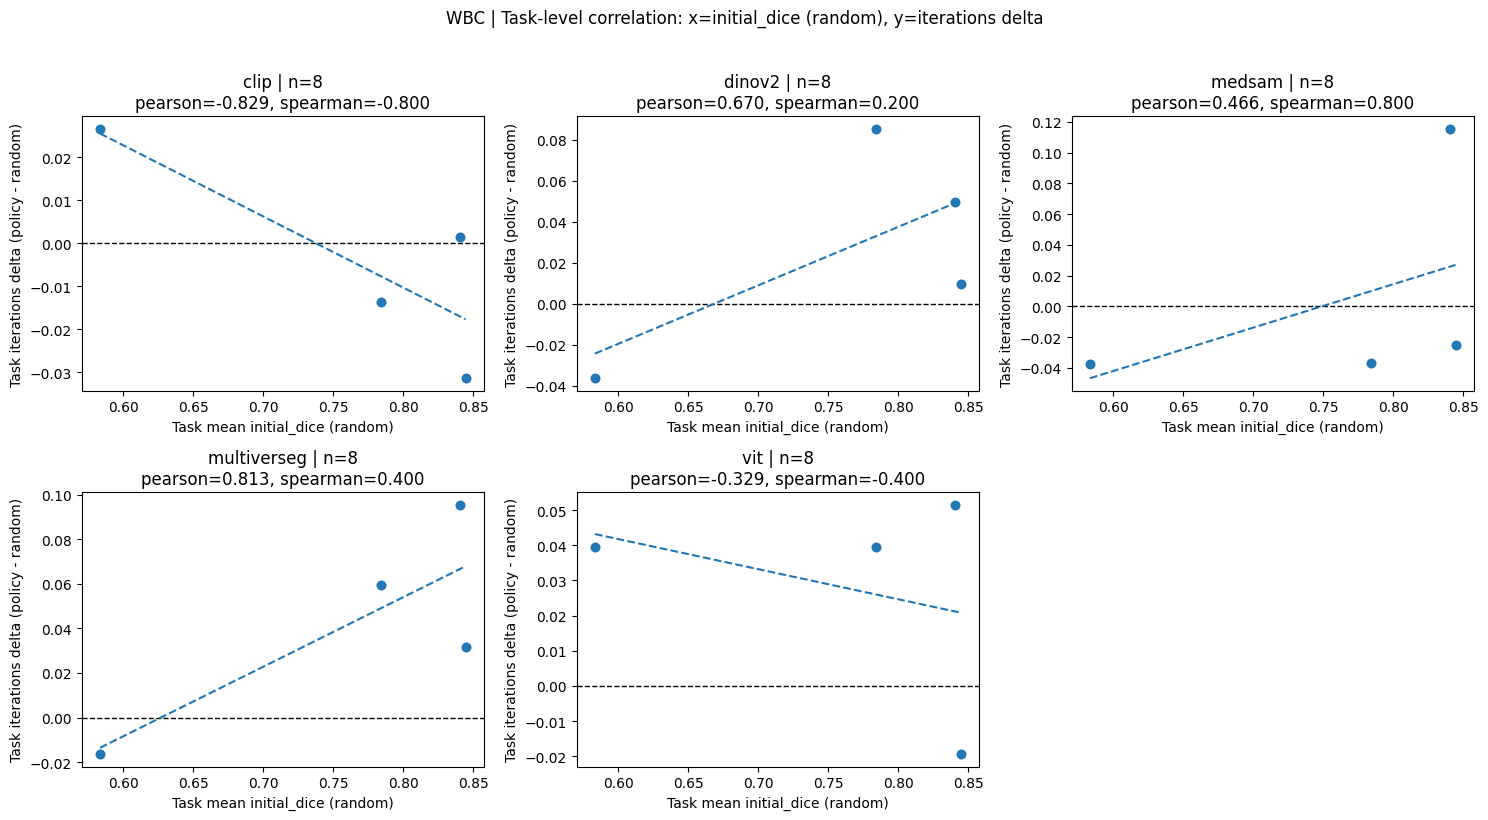

In [12]:
# Scatter plots for all datasets (one figure per family)
import math

for family in sorted(task_scatter_df['family'].unique()):
    fam_df = task_scatter_df[task_scatter_df['family'] == family]

    n_policies = len(encoder_policies)
    n_cols = 3
    n_rows = math.ceil(n_policies / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=False, sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for i, policy_name in enumerate(encoder_policies):
        ax = axes[i]
        policy_df = fam_df[fam_df['policy_name'] == policy_name]
        ax.scatter(policy_df['x_value'], policy_df['iterations_delta'], alpha=0.85)
        ax.axhline(0.0, color='black', linestyle='--', linewidth=1)

        # Trend line is just visual support for correlation.
        if len(policy_df) >= 2 and policy_df['x_value'].nunique() >= 2:
            m, b = np.polyfit(policy_df['x_value'].to_numpy(), policy_df['iterations_delta'].to_numpy(), 1)
            xs = np.linspace(float(policy_df['x_value'].min()), float(policy_df['x_value'].max()), 100)
            ax.plot(xs, m * xs + b, linestyle='--', linewidth=1.5)

        corr_row = task_corr_df[
            (task_corr_df['family'] == family) & (task_corr_df['policy_name'] == policy_name)
        ].iloc[0]
        pearson = corr_row['pearson_r']
        spearman = corr_row['spearman_r']
        ax.set_title(
            f"{_encoder_name(policy_name)} | n={int(corr_row['n_tasks'])}\n"
            f"pearson={pearson:.3f}, spearman={spearman:.3f}"
        )
        ax.set_xlabel(f"Task mean {task_x_metric} ({task_x_policy})")
        ax.set_ylabel('Task iterations delta (policy - random)')

    for j in range(n_policies, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'{family} | Task-level correlation: x={task_x_metric} ({task_x_policy}), y=iterations delta', y=1.02)
    fig.tight_layout()
    plt.show()


## Embedding signal check for MSE policies

This section checks whether the policy's embedding score aligns with observed click behavior.

For each MSE-embedding policy row (step >= 1), we compute:
- `x`: candidate distance to current context-mean embedding (same encoder used by that policy)
- `y`: either raw `iterations_used`, or `iterations_used(policy) - iterations_used(random)` at the same row key.


In [ ]:
# --- Embedding signal config ---
embedding_signal_split = 'train'      # split used to load image tensors for embedding extraction
embedding_signal_dataset_seed = 42
embedding_signal_device = 'cpu'       # set to 'cuda:0' for speed if available
embedding_signal_y_mode = 'delta_vs_random'  # options: 'delta_vs_random', 'iterations_used'
embedding_signal_min_context = 1

# Optional runtime controls
embedding_signal_max_tasks_per_family = None     # e.g., 5
embedding_signal_plot_max_points = 4000          # per family/policy for scatter display


In [ ]:
import json

import torch

from experiments.encoders.encoder_utils import build_encoder_from_cfg
from experiments.offline_active_learning.data_utils import build_task_dataset


def _load_policy_encoder_cfg(policy_name: str) -> dict:
    policy_sources = (
        analysis_df.loc[analysis_df['policy_name'] == policy_name, '__source__']
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    if not policy_sources:
        raise ValueError(f'No __source__ rows found for policy {policy_name}.')

    for source in policy_sources:
        b_dir = Path(source).parent
        metadata_path = b_dir / 'Subset_0' / 'run_metadata.json'
        if not metadata_path.exists():
            candidates = sorted(b_dir.glob('Subset_*/run_metadata.json'))
            if not candidates:
                continue
            metadata_path = candidates[0]

        metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
        encoder_cfg = metadata.get('ordering', {}).get('encoder_cfg')
        if encoder_cfg:
            return dict(encoder_cfg)

    raise ValueError(f'Could not find encoder_cfg in run metadata for policy {policy_name}.')


def _flatten_embedding(embedding_tensor: torch.Tensor) -> torch.Tensor:
    if embedding_tensor.ndim > 1:
        embedding_tensor = embedding_tensor.squeeze(0)
    return embedding_tensor.reshape(-1).to(torch.float32)


signal_df = analysis_df[analysis_df['policy_name'].isin([baseline_policy] + encoder_policies)].copy()
if embedding_signal_max_tasks_per_family is not None:
    keep_tasks = (
        signal_df[['family', 'task_id']]
        .drop_duplicates()
        .sort_values(['family', 'task_id'])
        .groupby('family', as_index=False)
        .head(int(embedding_signal_max_tasks_per_family))
    )
    signal_df = signal_df.merge(keep_tasks, on=['family', 'task_id'], how='inner')

policy_encoder_cfg = {policy_name: _load_policy_encoder_cfg(policy_name) for policy_name in encoder_policies}

embedding_device = torch.device(embedding_signal_device)
policy_encoders = {
    policy_name: build_encoder_from_cfg(cfg, device=embedding_device)
    for policy_name, cfg in policy_encoder_cfg.items()
}
for encoder in policy_encoders.values():
    encoder.eval()

baseline_key_cols = ['family', 'task_id', 'subset_index', 'permutation_index', 'image_index']
baseline_table = (
    signal_df[signal_df['policy_name'] == baseline_policy][baseline_key_cols + ['iterations_used']]
    .drop_duplicates(subset=baseline_key_cols, keep='first')
    .set_index(baseline_key_cols)['iterations_used']
)

task_dataset_cache: dict[str, object] = {}
embedding_cache: dict[tuple[str, str, int], torch.Tensor] = {}


def _task_dataset(task_id: str):
    if task_id not in task_dataset_cache:
        task_dataset_cache[task_id] = build_task_dataset(
            task_id=task_id,
            split=embedding_signal_split,
            dataset_seed=int(embedding_signal_dataset_seed),
        )
    return task_dataset_cache[task_id]


def _get_embedding(task_id: str, policy_name: str, image_id: int) -> torch.Tensor:
    key = (task_id, policy_name, int(image_id))
    cached = embedding_cache.get(key)
    if cached is not None:
        return cached

    dataset_obj = _task_dataset(task_id)
    image_tensor, _ = dataset_obj.get_item_by_data_index(int(image_id))
    image_tensor = image_tensor.to(embedding_device)

    with torch.no_grad():
        embedding_tensor = policy_encoders[policy_name](image_tensor).detach().cpu()

    embedding_vec = _flatten_embedding(embedding_tensor)
    embedding_cache[key] = embedding_vec
    return embedding_vec


group_cols = ['family', 'task_id', 'subset_index', 'permutation_index', 'policy_name']
policy_rows = signal_df[signal_df['policy_name'].isin(encoder_policies)].copy()
policy_rows = policy_rows.sort_values(group_cols + ['image_index']).reset_index(drop=True)

signal_rows = []
skip_missing_baseline = 0
skip_embedding_fetch = 0

for (family, task_id, subset_index, permutation_index, policy_name), group in policy_rows.groupby(group_cols, sort=False):
    ordered = group.sort_values('image_index')
    context_ids: list[int] = []

    for row in ordered.itertuples(index=False):
        image_index = int(row.image_index)
        candidate_id = int(row.image_id)

        if image_index < int(embedding_signal_min_context):
            context_ids.append(candidate_id)
            continue

        try:
            candidate_embedding = _get_embedding(task_id, policy_name, candidate_id)
            context_embeddings = [_get_embedding(task_id, policy_name, context_id) for context_id in context_ids]
        except Exception:
            skip_embedding_fetch += 1
            context_ids.append(candidate_id)
            continue

        context_mean = torch.stack(context_embeddings, dim=0).mean(dim=0)
        dist_mse = float(torch.mean((candidate_embedding - context_mean) ** 2).item())

        iter_used = float(row.iterations_used)
        y_value = iter_used
        baseline_iter = float('nan')

        if embedding_signal_y_mode == 'delta_vs_random':
            key = (family, task_id, int(subset_index), int(permutation_index), image_index)
            if key not in baseline_table.index:
                skip_missing_baseline += 1
                context_ids.append(candidate_id)
                continue
            baseline_iter = float(baseline_table.loc[key])
            y_value = iter_used - baseline_iter

        signal_rows.append(
            {
                'family': family,
                'task_id': task_id,
                'subset_index': int(subset_index),
                'permutation_index': int(permutation_index),
                'image_index': image_index,
                'context_size': int(getattr(row, 'context_size', image_index)),
                'policy_name': policy_name,
                'encoder': _encoder_name(policy_name),
                'candidate_image_id': candidate_id,
                'x_context_mean_mse': dist_mse,
                'iterations_used': iter_used,
                'random_iterations_used': baseline_iter,
                'y_signal': y_value,
                'initial_dice': float(row.initial_dice),
                'final_dice': float(row.final_dice),
            }
        )

        context_ids.append(candidate_id)

embedding_signal_df = pd.DataFrame(signal_rows).sort_values(
    ['family', 'encoder', 'task_id', 'subset_index', 'permutation_index', 'image_index']
).reset_index(drop=True)

print(f'Embedding-signal rows: {len(embedding_signal_df):,}')
print(f'Skipped rows (missing random match): {skip_missing_baseline:,}')
print(f'Skipped rows (embedding fetch issue): {skip_embedding_fetch:,}')
print(f'Cached task datasets: {len(task_dataset_cache)} | cached embeddings: {len(embedding_cache):,}')


In [ ]:
def _safe_corr(x: pd.Series, y: pd.Series, method: str) -> float:
    if len(x) < 3:
        return float('nan')
    if x.nunique() < 2 or y.nunique() < 2:
        return float('nan')
    return float(x.corr(y, method=method))


embedding_signal_corr = (
    embedding_signal_df
    .groupby(['family', 'policy_name', 'encoder'], as_index=False)
    .apply(
        lambda g: pd.Series(
            {
                'n_rows': int(len(g)),
                'pearson_r': _safe_corr(g['x_context_mean_mse'], g['y_signal'], method='pearson'),
                'spearman_r': _safe_corr(g['x_context_mean_mse'], g['y_signal'], method='spearman'),
                'y_mean': float(g['y_signal'].mean()),
            }
        )
    )
    .sort_values(['family', 'encoder'])
    .reset_index(drop=True)
)

embedding_signal_corr


In [ ]:
# Scatter: x=distance-to-context-mean (embedding MSE), y=signal
# y_signal is either iterations_used or delta_vs_random depending on config.
import math

for family in sorted(embedding_signal_df['family'].unique()):
    fam_df = embedding_signal_df[embedding_signal_df['family'] == family]
    n_policies = len(encoder_policies)
    n_cols = 3
    n_rows = math.ceil(n_policies / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=False, sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for idx, policy_name in enumerate(encoder_policies):
        ax = axes[idx]
        policy_df = fam_df[fam_df['policy_name'] == policy_name]
        if policy_df.empty:
            ax.set_visible(False)
            continue

        if embedding_signal_plot_max_points is not None and len(policy_df) > int(embedding_signal_plot_max_points):
            policy_df = policy_df.sample(int(embedding_signal_plot_max_points), random_state=seed)

        ax.scatter(policy_df['x_context_mean_mse'], policy_df['y_signal'], alpha=0.20, s=10)

        if embedding_signal_y_mode == 'delta_vs_random':
            ax.axhline(0.0, color='black', linestyle='--', linewidth=1)

        if len(policy_df) >= 2 and policy_df['x_context_mean_mse'].nunique() >= 2:
            m, b = np.polyfit(policy_df['x_context_mean_mse'].to_numpy(), policy_df['y_signal'].to_numpy(), 1)
            xs = np.linspace(float(policy_df['x_context_mean_mse'].min()), float(policy_df['x_context_mean_mse'].max()), 100)
            ax.plot(xs, m * xs + b, linestyle='--', linewidth=1.5)

        pearson = _safe_corr(policy_df['x_context_mean_mse'], policy_df['y_signal'], method='pearson')
        spearman = _safe_corr(policy_df['x_context_mean_mse'], policy_df['y_signal'], method='spearman')
        ax.set_title(
            f"{_encoder_name(policy_name)} | n={len(policy_df)}\n"
            f"pearson={pearson:.3f}, spearman={spearman:.3f}"
        )
        ax.set_xlabel('Candidate distance to context mean (embedding MSE)')
        ax.set_ylabel('y_signal')

    for j in range(n_policies, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'{family} | Embedding signal check ({embedding_signal_y_mode})', y=1.02)
    fig.tight_layout()
    plt.show()


In [ ]:
# Save embedding-signal artifacts
signal_tag = f'{embedding_signal_y_mode}_{embedding_signal_split}'
embedding_signal_csv = out_dir / f'{procedure}_{ablation}_{dataset or "all"}_embedding_signal_{signal_tag}.csv'
embedding_signal_corr_csv = out_dir / f'{procedure}_{ablation}_{dataset or "all"}_embedding_signal_corr_{signal_tag}.csv'

embedding_signal_df.to_csv(embedding_signal_csv, index=False)
embedding_signal_corr.to_csv(embedding_signal_corr_csv, index=False)

print(f'Wrote {embedding_signal_csv}')
print(f'Wrote {embedding_signal_corr_csv}')


In [13]:
# Save task-level analysis artifacts
task_scatter_csv = out_dir / f'{procedure}_{ablation}_{dataset or "all"}_task_scatter_iterations_delta_vs_{task_x_policy}_{task_x_metric}.csv'
task_corr_csv = out_dir / f'{procedure}_{ablation}_{dataset or "all"}_task_corr_iterations_delta_vs_{task_x_policy}_{task_x_metric}.csv'

task_scatter_df.to_csv(task_scatter_csv, index=False)
task_corr_df.to_csv(task_corr_csv, index=False)

print(f'Wrote {task_scatter_csv}')
print(f'Wrote {task_corr_csv}')


Wrote /data/ddmg/mvseg-ordering/figures/mse_context_mean_embedding_5p_pretrained_baseline/random_v_MSE_v2_pretrained_baseline5p_mse_embedding_context_mean_all_task_scatter_iterations_delta_vs_random_initial_dice.csv
Wrote /data/ddmg/mvseg-ordering/figures/mse_context_mean_embedding_5p_pretrained_baseline/random_v_MSE_v2_pretrained_baseline5p_mse_embedding_context_mean_all_task_corr_iterations_delta_vs_random_initial_dice.csv


In [14]:
# Save tables for downstream use
absolute_csv = out_dir / f'{procedure}_{ablation}_{dataset or "all"}_absolute_summary.csv'
delta_csv = out_dir / f'{procedure}_{ablation}_{dataset or "all"}_delta_vs_random_summary.csv'

absolute_summary.to_csv(absolute_csv, index=False)
delta_summary.to_csv(delta_csv, index=False)

print(f'Wrote {absolute_csv}')
print(f'Wrote {delta_csv}')


Wrote /data/ddmg/mvseg-ordering/figures/mse_context_mean_embedding_5p_pretrained_baseline/random_v_MSE_v2_pretrained_baseline5p_mse_embedding_context_mean_all_absolute_summary.csv
Wrote /data/ddmg/mvseg-ordering/figures/mse_context_mean_embedding_5p_pretrained_baseline/random_v_MSE_v2_pretrained_baseline5p_mse_embedding_context_mean_all_delta_vs_random_summary.csv
